In [31]:
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path

sc.settings.verbosity = 2

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"/"raw"
FIG_DIR = ROOT / "figures"

print(DATA_DIR)
print(FIG_DIR)

/Users/varsha/workspace/scrnaseq_biomarker_disc/data/raw
/Users/varsha/workspace/scrnaseq_biomarker_disc/figures


In [32]:
meta = pd.read_csv(DATA_DIR / "GSE96583_batch2.total.tsne.df.tsv.gz", sep="\t", index_col=0)

print(meta.shape)
meta.head()

(29065, 7)


,tsne1,tsne2,ind,stim,cluster,cell,multiplets
AAACATACAATGCC-1,-4.277833,-19.294709,107,ctrl,5,CD4 T cells,doublet
AAACATACATTTCC-1,-27.640373,14.966629,1016,ctrl,9,CD14+ Monocytes,singlet
AAACATACCAGAAA-1,-27.493646,28.924885,1256,ctrl,9,CD14+ Monocytes,singlet
AAACATACCAGCTA-1,-28.132584,24.925484,1256,ctrl,9,CD14+ Monocytes,doublet
AAACATACCATGCA-1,-10.468194,-5.984389,1488,ctrl,3,CD4 T cells,singlet


In [33]:
print(meta["stim"].value_counts())
print(meta["cell"].value_counts())

stim
ctrl    14619
stim    14446
Name: count, dtype: int64
cell
CD4 T cells          12033
CD14+ Monocytes       6447
B cells               2880
CD8 T cells           2634
NK cells              2330
FCGR3A+ Monocytes     1914
Dendritic cells        472
Megakaryocytes         346
Name: count, dtype: int64


In [34]:
print(meta["ind"].value_counts())

ind
1015    5841
1488    5290
1256    4726
1016    4178
1244    4005
101     2390
1039    1349
107     1286
Name: count, dtype: int64


In [35]:
import tarfile
import gzip
import scipy.io

RAW_TAR = DATA_DIR / "GSE96583_RAW.tar"

with tarfile.open(RAW_TAR) as tar:
    members = {m.name: m for m in tar.getmembers()}
    print(list(members.keys()))

['GSM2560245_A.mat.gz', 'GSM2560245_barcodes.tsv.gz', 'GSM2560246_B.mat.gz', 'GSM2560246_barcodes.tsv.gz', 'GSM2560247_C.mat.gz', 'GSM2560247_barcodes.tsv.gz', 'GSM2560248_2.1.mtx.gz', 'GSM2560248_barcodes.tsv.gz', 'GSM2560249_2.2.mtx.gz', 'GSM2560249_barcodes.tsv.gz']


In [36]:
with tarfile.open(RAW_TAR) as tar:
    members = {m.name: m for m in tar.getmembers()}

    #load barcodes
    bc_file = tar.extractfile(members["GSM2560248_barcodes.tsv.gz"])
    with gzip.open(bc_file) as f:
        barcodes_ctrl = [line.decode().strip() for line in f]

    #load count matrix
    mtx_file = tar.extractfile(members["GSM2560248_2.1.mtx.gz"])
    with gzip.open(mtx_file) as f:
        mtx_ctrl = scipy.io.mmread(f).T.tocsr()
    
print(mtx_ctrl.shape)
print(f"Number of barcodes: {len(barcodes_ctrl)}")
print(f"First 3 barcodes: {barcodes_ctrl[:3]}")


(14619, 35635)
Number of barcodes: 14619
First 3 barcodes: ['AAACATACAATGCC-1', 'AAACATACATTTCC-1', 'AAACATACCAGAAA-1']


In [37]:
with tarfile.open(RAW_TAR) as tar:
    members = {m.name: m for m in tar.getmembers()}

    #load barcodes
    bc_file = tar.extractfile(members["GSM2560249_barcodes.tsv.gz"])
    with gzip.open(bc_file) as f:
        barcodes_stim = [line.decode().strip() for line in f]

    #load count matrix
    mtx_file = tar.extractfile(members["GSM2560249_2.2.mtx.gz"])
    with gzip.open(mtx_file) as f:
        mtx_stim = scipy.io.mmread(f).T.tocsr()
    
print(mtx_stim.shape)
print(f"Number of barcodes: {len(barcodes_stim)}")
print(f"First 3 barcodes: {barcodes_stim[:3]}")

(14446, 35635)
Number of barcodes: 14446
First 3 barcodes: ['AAACATACCAAGCT-1', 'AAACATACCCCTAC-1', 'AAACATACCCGTAA-1']


In [38]:
genes = pd.read_csv(DATA_DIR / "GSE96583_batch2.genes.tsv.gz", sep="\t", header=None, names=["ensemblgene_id", "gene_symbol"])
print(genes.shape)
genes.head()

(35635, 2)


,ensemblgene_id,gene_symbol
0,ENSG00000243485,MIR1302-10
1,ENSG00000237613,FAM138A
2,ENSG00000186092,OR4F5
3,ENSG00000238009,RP11-34P13.7
4,ENSG00000239945,RP11-34P13.8


In [39]:
# build AnnData objects for control and stimulated samples

import anndata as ad

var = pd.DataFrame({"gene_symbol": genes["gene_symbol"].values}, index=genes["ensemblgene_id"].values)

adata_ctrl = ad.AnnData(X=mtx_ctrl, obs=pd.DataFrame(index=barcodes_ctrl), var=var)

adata_stim = ad.AnnData(X=mtx_stim, obs=pd.DataFrame(index=barcodes_stim), var=var)

print(adata_ctrl)
print(adata_stim)

AnnData object with n_obs × n_vars = 14619 × 35635
    var: 'gene_symbol'
AnnData object with n_obs × n_vars = 14446 × 35635
    var: 'gene_symbol'


In [40]:
# concatenate the two AnnData objects into a single object
adata_combined = ad.concat([adata_ctrl, adata_stim], label="sample", keys=["ctrl", "stim"])
print(adata_combined)
print(adata_combined.obs.head())

AnnData object with n_obs × n_vars = 29065 × 35635
    obs: 'sample'
                 sample
AAACATACAATGCC-1   ctrl
AAACATACATTTCC-1   ctrl
AAACATACCAGAAA-1   ctrl
AAACATACCAGCTA-1   ctrl
AAACATACCATGCA-1   ctrl


/Users/varsha/miniforge3/envs/scrnaseq-biomarker/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [41]:
adata_combined.obs_names_make_unique()
print(adata_combined.obs_names.is_unique)

True


In [42]:
adata_combined.obs = adata_combined.obs.join(meta[["ind", "stim", "cell", "multiplets"]])
adata_combined.obs.rename(columns={"ind": "donor", "stim": "condition", "cell": "cell_type"}, inplace=True)
print(adata_combined.obs.head())
print(adata_combined.obs.shape)
print(adata_combined.obs.isna().sum())

                 sample   donor condition        cell_type multiplets
AAACATACAATGCC-1   ctrl   107.0      ctrl      CD4 T cells    doublet
AAACATACATTTCC-1   ctrl  1016.0      ctrl  CD14+ Monocytes    singlet
AAACATACCAGAAA-1   ctrl  1256.0      ctrl  CD14+ Monocytes    singlet
AAACATACCAGCTA-1   ctrl  1256.0      ctrl  CD14+ Monocytes    doublet
AAACATACCATGCA-1   ctrl  1488.0      ctrl      CD4 T cells    singlet
(29065, 5)
sample          0
donor         313
condition     313
cell_type     322
multiplets    313
dtype: int64


In [43]:
adata_combined.layers["counts"] = adata_combined.X.copy()

In [44]:
print(adata_combined)

AnnData object with n_obs × n_vars = 29065 × 35635
    obs: 'sample', 'donor', 'condition', 'cell_type', 'multiplets'
    layers: 'counts'


In [45]:
#count mitochondrial genes
#adata_combined.var["mt"] = adata_combined.var["gene_symbol"].str.startswith("MT-")
#print(adata_combined.var["mt"].sum())
print(adata_combined.var.columns)
print(adata_ctrl.var.head())

Index([], dtype='object')
                  gene_symbol
ENSG00000243485    MIR1302-10
ENSG00000237613       FAM138A
ENSG00000186092         OR4F5
ENSG00000238009  RP11-34P13.7
ENSG00000239945  RP11-34P13.8


In [46]:
adata_combined.var["gene_symbol"] = genes["gene_symbol"].values
print(adata_combined.var.head())

                  gene_symbol
ENSG00000243485    MIR1302-10
ENSG00000237613       FAM138A
ENSG00000186092         OR4F5
ENSG00000238009  RP11-34P13.7
ENSG00000239945  RP11-34P13.8


In [47]:
#count mitochondrial genes
adata_combined.var["mt"] = adata_combined.var["gene_symbol"].str.startswith("MT-")
print(adata_combined.var["mt"].sum())

13


In [48]:
# compute QC metrics
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
print(adata_combined.obs.columns.tolist())

['sample', 'donor', 'condition', 'cell_type', 'multiplets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


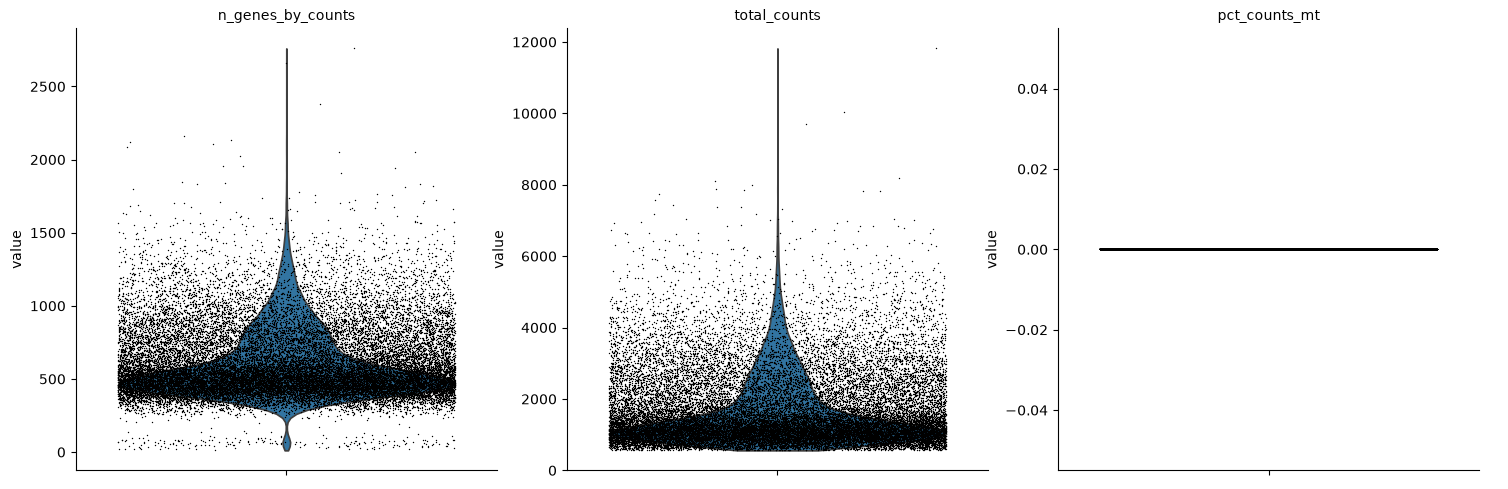

In [49]:
sc.pl.violin(adata_combined, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

In [50]:
print(adata_combined.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe())

       n_genes_by_counts  total_counts  pct_counts_mt
count       29065.000000  29065.000000        29065.0
mean          604.536212   1672.146052            0.0
std           237.425201   1007.676274            0.0
min            12.000000    562.000000            0.0
25%           445.000000    987.000000            0.0
50%           533.000000   1301.000000            0.0
75%           718.000000   2079.000000            0.0
max          2760.000000  11819.000000            0.0


In [51]:
print(adata_combined.var[adata_combined.var["mt"] == True]["gene_symbol"])

ENSG00000198888     MT-ND1
ENSG00000198763     MT-ND2
ENSG00000198804     MT-CO1
ENSG00000198712     MT-CO2
ENSG00000228253    MT-ATP8
ENSG00000198899    MT-ATP6
ENSG00000198938     MT-CO3
ENSG00000198840     MT-ND3
ENSG00000212907    MT-ND4L
ENSG00000198886     MT-ND4
ENSG00000198786     MT-ND5
ENSG00000198695     MT-ND6
ENSG00000198727     MT-CYB
Name: gene_symbol, dtype: category
Categories (32938, object): ['5S_rRNA', '7SK', 'A1BG', 'A1BG-AS1', ..., 'hsa-mir-1253', 'hsa-mir-7515', 'hsa-mir-8072', 'snoU13']


In [52]:
sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_cells(adata_combined, max_counts=10000)
sc.pp.filter_cells(adata_combined, max_genes=2500)

filtered out 194 cells that have less than 200 genes expressed
filtered out 2 cells that have more than 10000 counts


In [53]:
# count the number of cells remaining after filtering
print(adata_combined.shape)

(28869, 35635)


In [54]:
# filter out cells with missing metadata
adata_combined = adata_combined[adata_combined.obs["cell_type"].notna()].copy()
print(adata_combined.shape)

(28557, 35635)


In [55]:
# filter out genes that are expressed in fewer than 10 cells
sc.pp.filter_genes(adata_combined, min_cells=10)
print(adata_combined.shape)

filtered out 21908 genes that are detected in less than 10 cells
(28557, 13727)


In [56]:
# normalize the data to counts per 10,000 and log-transform
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)

normalizing counts per cell
    finished (0:00:00)


In [57]:
print(adata_combined.X[0, :10])
print(adata_combined.layers["counts"][0, :10])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (1, 10)>
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (1, 10)>


In [59]:
# find a cell with many genes detected
idx = np.argmax(adata_combined.obs["n_genes_by_counts"])
print("Raw counts:", adata_combined.layers["counts"][idx, :10].toarray())
print("Normalized:", adata_combined.X[idx, :10].toarray())

Raw counts: [[  0.   0.   0.   0.   0.   0.   0. 151.   0.   0.]]
Normalized: [[0.         0.         0.         0.         0.         0.
  0.         5.05650116 0.         0.        ]]


In [60]:
print(adata_combined.layers["counts"][idx].sum())

9677.0


In [61]:
raw = adata_combined.layers["counts"][idx, 7]
total = adata_combined.layers["counts"][idx].sum()
normalized = (raw/total) * 1e4
import numpy as np
log_normalized = np.log1p(normalized)
print(f"Raw counts: {raw}")
print(f"Total counts: {total}")
print(f"Normalized counts: {normalized}")
print(f"Log-normalized counts: {log_normalized}")

Raw counts: 151.0
Total counts: 9677.0
Normalized counts: 156.0400950707864
Log-normalized counts: 5.056501155360192


In [62]:
# select the top 2000 highly variable genes
sc.pp.highly_variable_genes(adata_combined, n_top_genes=2000, flavor="seurat_v3", subset=False, layer="counts", batch_key="donor")
print(adata_combined.var["highly_variable"].sum())

extracting highly variable genes
2000


In [63]:
# save the preprocessed AnnData object to a file
adata_combined.write_h5ad("preprocessed_data.h5ad")
print("Saved!")

Saved!
